# SVM con kernel RBF: classificazione di feature reali e sintetiche

Obiettivo: confrontare le rappresentazioni tabulari deterministiche GAP e mean+std mediante una SVM RBF calibrata. La selezione usa esclusivamente la balanced accuracy di validation; il test viene usato una sola volta, dopo il blocco di iperparametri e soglia.

Input: cache tabulari create da dataset_exploration.ipynb. Hardware previsto: CPU locale; CUDA non è necessaria per scikit-learn.

## 1. Setup portabile e riproducibilità

Questa è l'unica cella con logica specifica di piattaforma. In Colab monta Drive e replica i file originali nella VM; in locale usa la root del repository. Le cache e gli output vengono sempre letti o scritti nelle directory astratte configurate qui.

In [1]:
# Rilevamento robusto: l'assenza del namespace google in locale non deve causare un errore.
from pathlib import Path
import importlib.util
import shutil

try:
    from google.colab import drive as colab_drive
    IS_COLAB = True
except ImportError:
    colab_drive = None
    IS_COLAB = False

EXPECTED_FILES = {'features_0.npy': 2_167_931_008, 'features_1.npy': 3_123_445_888}
if IS_COLAB:
    DRIVE_MOUNT = Path('/content/drive')
    if not (DRIVE_MOUNT / 'MyDrive').exists():
        colab_drive.mount(str(DRIVE_MOUNT), force_remount=False)
    PROJECT_ROOT = DRIVE_MOUNT / 'MyDrive' / 'Magistrale' / 'Advanced_ML' / 'progetto_aml'
    PERSISTENT_DATASET_DIR = PROJECT_ROOT / 'dataset'
    if not PERSISTENT_DATASET_DIR.is_dir():
        raise FileNotFoundError(f'Dataset directory non trovata su Drive: {PERSISTENT_DATASET_DIR}')
    RUNTIME_DATASET_DIR = Path('/content/progetto_aml/dataset')
    RUNTIME_DATASET_DIR.mkdir(parents=True, exist_ok=True)
    # I file originali restano immutati su Drive; nella VM viene mantenuta solo una cache temporanea verificata per dimensione.
    for filename, expected_size in EXPECTED_FILES.items():
        source, destination = PERSISTENT_DATASET_DIR / filename, RUNTIME_DATASET_DIR / filename
        if not source.is_file():
            raise FileNotFoundError(f'File originale mancante: {source}')
        if source.stat().st_size != expected_size:
            raise RuntimeError(f'Dimensione inattesa per {source}: {source.stat().st_size}; attesi {expected_size}')
        if not destination.exists() or destination.stat().st_size != expected_size:
            print(f'Copio {filename} da Drive nella VM Colab')
            shutil.copy2(source, destination)
        if destination.stat().st_size != expected_size:
            raise RuntimeError(f'Copia incompleta: {destination}')
    DATASET_DIR = RUNTIME_DATASET_DIR
    PROCESSED_DATASET_DIR = PERSISTENT_DATASET_DIR
    ARTIFACTS_DIR, RESULTS_DIR = PROJECT_ROOT / 'artifacts', PROJECT_ROOT / 'results'
else:
    PROJECT_ROOT = Path.cwd()
    if not (PROJECT_ROOT / 'dataset').is_dir():
        PROJECT_ROOT = PROJECT_ROOT.parent
    PERSISTENT_DATASET_DIR = PROJECT_ROOT / 'dataset'
    DATASET_DIR = PERSISTENT_DATASET_DIR
    PROCESSED_DATASET_DIR = PERSISTENT_DATASET_DIR
    ARTIFACTS_DIR, RESULTS_DIR = PROJECT_ROOT / 'artifacts', PROJECT_ROOT / 'results'

if not PERSISTENT_DATASET_DIR.is_dir():
    raise FileNotFoundError(f'Dataset directory non trovata: {PERSISTENT_DATASET_DIR}')
for directory in (ARTIFACTS_DIR, RESULTS_DIR):
    directory.mkdir(parents=True, exist_ok=True)
print('Ambiente:', 'Google Colab' if IS_COLAB else 'Locale')
print('Cache persistenti:', PROCESSED_DATASET_DIR)
print('Output persistenti:', RESULTS_DIR)

Ambiente: Locale
Cache persistenti: c:\Users\leona\venv_aml\dataset
Output persistenti: c:\Users\leona\venv_aml\results


In [2]:
# Dipendenze minime e configurazione centralizzata; nessuna GPU è richiesta dalla SVM.
import subprocess
import sys

required_packages = {'numpy': 'numpy', 'pandas': 'pandas', 'matplotlib': 'matplotlib', 'sklearn': 'scikit-learn', 'joblib': 'joblib'}
missing_packages = [package for module, package in required_packages.items() if importlib.util.find_spec(module) is None]
if missing_packages:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '--quiet', *missing_packages])

import hashlib
import json
import os
import platform
import random
import time
from datetime import datetime, timezone
from itertools import product

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, average_precision_score, balanced_accuracy_score, brier_score_loss, confusion_matrix, f1_score, hinge_loss, precision_recall_curve, precision_score, recall_score, roc_auc_score, roc_curve
from sklearn.model_selection import StratifiedKFold, learning_curve, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

try:
    import torch
except ImportError:
    torch = None
try:
    import xgboost
except ImportError:
    xgboost = None

SEED = 42
POOLING_CHOICES = ('mean_std', 'gap')
C_VALUES = (0.1, 1.0, 10.0, 100.0)
GAMMA_VALUES = ('scale', 1e-4, 5e-4, 1e-3)
CLASS_WEIGHTS = (None, 'balanced')
# La configurazione primaria non usa PCA. Impostare True soltanto per svolgere l'ablation PCA selezionata su validation.
ENABLE_PCA_ABLATION = False
PCA_OPTIONS = (None, 256, 512, 0.95) if ENABLE_PCA_ABLATION else (None,)
CALIBRATION_FOLDS = 5
LEARNING_CURVE_FOLDS = 5
LEARNING_CURVE_TRAIN_SIZES = np.linspace(0.2, 1.0, 5)
RUN_ID = f'seed{SEED}_{datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%SZ")}'
MODEL_NAME = 'svm_rbf'
RUN_DIR = RESULTS_DIR / MODEL_NAME / RUN_ID
FIGURES_DIR = RUN_DIR / 'figures'
RUN_DIR.mkdir(parents=True, exist_ok=False)
FIGURES_DIR.mkdir(parents=True, exist_ok=False)

random.seed(SEED)
np.random.seed(SEED)
if torch is not None:
    torch.manual_seed(SEED)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(SEED)
versions = {'python': platform.python_version(), 'numpy': np.__version__, 'pandas': pd.__version__, 'scikit_learn': __import__('sklearn').__version__, 'xgboost': None if xgboost is None else xgboost.__version__, 'pytorch': None if torch is None else torch.__version__, 'cuda': None if torch is None or not torch.cuda.is_available() else torch.version.cuda}
print(json.dumps(versions, indent=2))
print('Run directory:', RUN_DIR)

{
  "python": "3.12.10",
  "numpy": "2.5.2",
  "pandas": "3.0.5",
  "scikit_learn": "1.9.1",
  "xgboost": "3.4.1",
  "pytorch": "2.14.0+cu126",
  "cuda": "12.6"
}
Run directory: c:\Users\leona\venv_aml\results\svm_rbf\seed42_20260916T133639Z


## 2. Convenzioni di classe, split e funzioni di supporto

Il mapping è esplicito: fake è sempre la classe positiva. Lo split condiviso viene caricato e validato; soltanto se manca viene creato mediante lo stesso split stratificato del notebook esplorativo.

In [3]:
# La pipeline non deduce le label dal nome dei file, per evitare ambiguità tra notebook.
CLASS_MAPPING = {'features_0.npy': {'label': 0, 'name': 'real'}, 'features_1.npy': {'label': 1, 'name': 'fake'}}
POSITIVE_LABEL, POSITIVE_CLASS = 1, 'fake'
assert CLASS_MAPPING['features_1.npy'] == {'label': POSITIVE_LABEL, 'name': POSITIVE_CLASS}
N_REAL, N_FAKE, N_TOTAL = 1654, 2383, 4037
labels = np.concatenate((np.zeros(N_REAL, dtype=np.int8), np.ones(N_FAKE, dtype=np.int8)))

def atomic_json(payload, path):
    temporary = path.with_name(path.name + '.tmp')
    with temporary.open('w', encoding='utf-8') as handle:
        json.dump(payload, handle, indent=2, ensure_ascii=False, default=str)
    os.replace(temporary, path)

def atomic_csv(frame, path):
    temporary = path.with_name(path.name + '.tmp')
    frame.to_csv(temporary, index=False)
    os.replace(temporary, path)

def save_split(path, train_indices, validation_indices, test_indices):
    temporary = path.with_name(path.name + '.tmp')
    with temporary.open('wb') as handle:
        np.savez_compressed(handle, train_indices=train_indices, validation_indices=validation_indices, test_indices=test_indices)
    os.replace(temporary, path)

def stable_split_hash(train_indices, validation_indices, test_indices):
    digest = hashlib.sha256()
    for name, values in (('train', train_indices), ('validation', validation_indices), ('test', test_indices)):
        digest.update(name.encode('utf-8'))
        digest.update(np.asarray(values, dtype='<i8').tobytes())
    return digest.hexdigest()

def validate_splits(train_indices, validation_indices, test_indices):
    parts = [np.asarray(values, dtype=np.int64) for values in (train_indices, validation_indices, test_indices)]
    merged = np.concatenate(parts)
    if len(np.unique(merged)) != N_TOTAL or set(merged) != set(range(N_TOTAL)):
        raise RuntimeError('Split non disgiunti oppure non esaustivi')
    if any(values.min() < 0 or values.max() >= N_TOTAL for values in parts):
        raise RuntimeError('Indice di split fuori range')
    return {name: {'n_samples': int(len(values)), 'real': int((labels[values] == 0).sum()), 'fake': int((labels[values] == 1).sum())} for name, values in zip(('train', 'validation', 'test'), parts)}

SPLIT_PATH = ARTIFACTS_DIR / 'splits_seed42.npz'
if SPLIT_PATH.exists():
    with np.load(SPLIT_PATH, allow_pickle=False) as split_archive:
        train_indices = split_archive['train_indices'].astype(np.int64, copy=False)
        validation_indices = split_archive['validation_indices'].astype(np.int64, copy=False)
        test_indices = split_archive['test_indices'].astype(np.int64, copy=False)
    split_origin = 'loaded'
else:
    # Replica esattamente la strategia del notebook esplorativo, senza osservare alcuna feature.
    all_indices = np.arange(N_TOTAL, dtype=np.int64)
    train_indices, holdout_indices = train_test_split(all_indices, test_size=0.30, stratify=labels, random_state=SEED)
    validation_indices, test_indices = train_test_split(holdout_indices, test_size=0.50, stratify=labels[holdout_indices], random_state=SEED)
    train_indices, validation_indices, test_indices = map(np.sort, (train_indices, validation_indices, test_indices))
    save_split(SPLIT_PATH, train_indices, validation_indices, test_indices)
    split_origin = 'created'
SPLIT_SUMMARY = validate_splits(train_indices, validation_indices, test_indices)
SPLIT_HASH = stable_split_hash(train_indices, validation_indices, test_indices)
print('Split:', split_origin, SPLIT_HASH)
print(json.dumps(SPLIT_SUMMARY, indent=2))

Split: loaded e23bd01e9ec079e665ed5cb58cdba6c190d40bb702919412e2f5f5aeca63cbd6
{
  "train": {
    "n_samples": 2825,
    "real": 1157,
    "fake": 1668
  },
  "validation": {
    "n_samples": 606,
    "real": 248,
    "fake": 358
  },
  "test": {
    "n_samples": 606,
    "real": 249,
    "fake": 357
  }
}


## 3. Caricamento e validazione delle cache

Le cache vengono generate dal notebook esplorativo e sono allineate riga-per-riga a sample_index.csv. Questo notebook interrompe l'esecuzione in presenza di cache mancanti, forme errate, valori non finiti o metadata incoerenti.

In [4]:
# La SVM opera sulle cache tabulari; non carica né modifica i grandi tensori spaziali originali.
GAP_PATH = PROCESSED_DATASET_DIR / 'tabular_features_gap.npy'
MEAN_STD_PATH = PROCESSED_DATASET_DIR / 'tabular_features_mean_std.npy'
SAMPLE_INDEX_PATH = PROCESSED_DATASET_DIR / 'sample_index.csv'
for required_path in (GAP_PATH, MEAN_STD_PATH, SAMPLE_INDEX_PATH):
    if not required_path.is_file():
        raise FileNotFoundError(f'Artefatto di preprocessing mancante: {required_path}. Eseguire prima dataset_exploration.ipynb.')

gap_features = np.load(GAP_PATH, mmap_mode='r', allow_pickle=False)
mean_std_features = np.load(MEAN_STD_PATH, mmap_mode='r', allow_pickle=False)
sample_index = pd.read_csv(SAMPLE_INDEX_PATH)
required_columns = ['sample_id', 'source_file', 'source_index', 'label', 'split']
if sample_index.columns.tolist() != required_columns:
    raise RuntimeError(f'Colonne sample_index inattese: {sample_index.columns.tolist()}')
if gap_features.shape != (N_TOTAL, 1280) or mean_std_features.shape != (N_TOTAL, 2560):
    raise RuntimeError(f'Forme cache inattese: GAP={gap_features.shape}, mean_std={mean_std_features.shape}')
if gap_features.dtype != np.float32 or mean_std_features.dtype != np.float32:
    raise RuntimeError('Le cache devono essere float32')
if len(sample_index) != N_TOTAL or not np.array_equal(sample_index['label'].to_numpy(dtype=np.int8), labels):
    raise RuntimeError('sample_index non è allineato alle label attese')
expected_splits = np.full(N_TOTAL, 'unassigned', dtype=object)
expected_splits[train_indices], expected_splits[validation_indices], expected_splits[test_indices] = 'train', 'validation', 'test'
if not np.array_equal(sample_index['split'].to_numpy(), expected_splits):
    raise RuntimeError('sample_index non è allineato allo split condiviso')

# Controllo esplicito: non si applica imputazione, perché NaN o Inf invaliderebbero il risultato sperimentale.
for name, features in (('GAP', gap_features), ('mean+std', mean_std_features)):
    if not np.isfinite(features).all():
        raise ValueError(f'Valori NaN o Inf trovati nella cache {name}')
print('GAP:', gap_features.shape, gap_features.dtype)
print('mean+std:', mean_std_features.shape, mean_std_features.dtype)
print('sample_index:', len(sample_index), 'righe')

GAP: (4037, 1280) float32
mean+std: (4037, 2560) float32
sample_index: 4037 righe


## 4. Pipeline, ricerca degli iperparametri e selezione

Per ogni rappresentazione, StandardScaler e PCA opzionale sono dentro la pipeline: ciò garantisce che siano fit soltanto sul training. La griglia è valutata sul validation set con balanced accuracy; il test non viene consultato in questa sezione.

In [5]:
def make_svm_pipeline(c_value, gamma_value, class_weight, pca_option):
    # Il fit di scaler e PCA avviene quando pipeline.fit riceve soltanto X_train.
    steps = [('scaler', StandardScaler())]
    if pca_option is not None:
        if isinstance(pca_option, float):
            steps.append(('pca', PCA(n_components=pca_option, svd_solver='full', random_state=SEED)))
        else:
            steps.append(('pca', PCA(n_components=pca_option, svd_solver='randomized', random_state=SEED)))
    steps.append(('svm', SVC(C=c_value, gamma=gamma_value, kernel='rbf', class_weight=class_weight, probability=False, random_state=SEED)))
    return Pipeline(steps)

feature_sets = {'mean_std': mean_std_features, 'gap': gap_features}
tuning_rows = []
best_selection = None
tuning_started = time.perf_counter()
for pooling_name in POOLING_CHOICES:
    features = feature_sets[pooling_name]
    X_train, X_validation = np.asarray(features[train_indices], dtype=np.float32), np.asarray(features[validation_indices], dtype=np.float32)
    y_train, y_validation = labels[train_indices], labels[validation_indices]
    for c_value, gamma_value, class_weight, pca_option in product(C_VALUES, GAMMA_VALUES, CLASS_WEIGHTS, PCA_OPTIONS):
        candidate = make_svm_pipeline(c_value, gamma_value, class_weight, pca_option)
        fit_started = time.perf_counter()
        candidate.fit(X_train, y_train)
        validation_margin = candidate.decision_function(X_validation)
        validation_prediction = (validation_margin >= 0.0).astype(np.int8)
        validation_score = balanced_accuracy_score(y_validation, validation_prediction)
        row = {'pooling': pooling_name, 'C': c_value, 'gamma': gamma_value, 'class_weight': 'balanced' if class_weight == 'balanced' else 'none', 'pca': 'none' if pca_option is None else str(pca_option), 'validation_balanced_accuracy': float(validation_score), 'fit_seconds': time.perf_counter() - fit_started}
        tuning_rows.append(row)
        if best_selection is None or validation_score > best_selection['validation_balanced_accuracy']:
            best_selection = {**row, 'class_weight_value': class_weight, 'pca_option': pca_option}
tuning_seconds = time.perf_counter() - tuning_started
tuning_frame = pd.DataFrame(tuning_rows).sort_values('validation_balanced_accuracy', ascending=False).reset_index(drop=True)
atomic_csv(tuning_frame, RUN_DIR / 'tuning_results.csv')
print('Configurazione selezionata su validation:')
print(best_selection)
print(f'Tuning: {tuning_seconds:.1f} s, {len(tuning_frame)} configurazioni')

c:\Users\leona\venv_aml\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Users\leona\venv_aml\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Users\leona\venv_aml\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Users\leona\venv_aml\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed i

Configurazione selezionata su validation:
{'pooling': 'gap', 'C': 10.0, 'gamma': 'scale', 'class_weight': 'none', 'pca': 'none', 'validation_balanced_accuracy': 0.9730131555235177, 'fit_seconds': 2.7480326000004425, 'class_weight_value': None, 'pca_option': None}
Tuning: 421.4 s, 64 configurazioni


## 5. Calibrazione sul training e soglia selezionata su validation

Dopo la scelta degli iperparametri, la probabilità viene calibrata con sigmoid calibration cross-validated esclusivamente sul training. La soglia viene cercata sulla validation e poi resta immutabile per train, validation e test.

In [6]:
selected_pooling = best_selection['pooling']
selected_features = feature_sets[selected_pooling]
X_train = np.asarray(selected_features[train_indices], dtype=np.float32)
X_validation = np.asarray(selected_features[validation_indices], dtype=np.float32)
X_test = np.asarray(selected_features[test_indices], dtype=np.float32)
y_train, y_validation, y_test = labels[train_indices], labels[validation_indices], labels[test_indices]

# selection_model conserva i margini RBF; calibrated_model produce probabilità confrontabili per l'ensemble.
selection_model = make_svm_pipeline(best_selection['C'], best_selection['gamma'], best_selection['class_weight_value'], best_selection['pca_option'])
selection_model.fit(X_train, y_train)
calibration_cv = StratifiedKFold(n_splits=CALIBRATION_FOLDS, shuffle=True, random_state=SEED)
try:
    calibrated_model = CalibratedClassifierCV(estimator=make_svm_pipeline(best_selection['C'], best_selection['gamma'], best_selection['class_weight_value'], best_selection['pca_option']), method='sigmoid', cv=calibration_cv)
except TypeError:
    # Compatibilità con versioni scikit-learn che chiamano ancora il parametro base_estimator.
    calibrated_model = CalibratedClassifierCV(base_estimator=make_svm_pipeline(best_selection['C'], best_selection['gamma'], best_selection['class_weight_value'], best_selection['pca_option']), method='sigmoid', cv=calibration_cv)
calibration_started = time.perf_counter()
calibrated_model.fit(X_train, y_train)
calibration_seconds = time.perf_counter() - calibration_started
validation_probability = calibrated_model.predict_proba(X_validation)[:, POSITIVE_LABEL]

def choose_threshold(y_true, probabilities):
    # Una griglia fissa è riproducibile; il test non partecipa a questa scelta.
    candidates = np.linspace(0.01, 0.99, 99)
    scores = [balanced_accuracy_score(y_true, probabilities >= threshold) for threshold in candidates]
    best_position = int(np.argmax(scores))
    return float(candidates[best_position]), float(scores[best_position])

DECISION_THRESHOLD, validation_threshold_score = choose_threshold(y_validation, validation_probability)
print(f'Calibrazione training-only: {calibration_seconds:.1f} s')
print(f'Soglia bloccata dalla validation: {DECISION_THRESHOLD:.2f}; balanced accuracy validation: {validation_threshold_score:.4f}')

c:\Users\leona\venv_aml\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Users\leona\venv_aml\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Users\leona\venv_aml\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Users\leona\venv_aml\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed i

Calibrazione training-only: 10.4 s
Soglia bloccata dalla validation: 0.57; balanced accuracy validation: 0.9777


## 6. Valutazione finale e predizioni per campione

La stessa funzione produce metriche e predizioni per train, validation e test. Il test è valutato soltanto ora, dopo tutte le decisioni di tuning, calibrazione e soglia.

In [7]:
def evaluate_split(split_name, indices, features, y_true):
    inference_started = time.perf_counter()
    raw_margin = selection_model.decision_function(features)
    probability = calibrated_model.predict_proba(features)[:, POSITIVE_LABEL]
    inference_seconds = time.perf_counter() - inference_started
    prediction = (probability >= DECISION_THRESHOLD).astype(np.int8)
    matrix = confusion_matrix(y_true, prediction, labels=[0, 1])
    tn, fp, fn, tp = matrix.ravel()
    metrics = {'run_id': RUN_ID, 'model': MODEL_NAME, 'split': split_name, 'n_samples': int(len(y_true)), 'loss': float(hinge_loss(y_true, raw_margin, labels=[0, 1])), 'accuracy': float(accuracy_score(y_true, prediction)), 'balanced_accuracy': float(balanced_accuracy_score(y_true, prediction)), 'precision': float(precision_score(y_true, prediction, pos_label=POSITIVE_LABEL, zero_division=0)), 'recall': float(recall_score(y_true, prediction, pos_label=POSITIVE_LABEL, zero_division=0)), 'specificity': float(tn / (tn + fp)) if (tn + fp) else float('nan'), 'f1': float(f1_score(y_true, prediction, pos_label=POSITIVE_LABEL, zero_division=0)), 'roc_auc': float(roc_auc_score(y_true, probability)), 'pr_auc': float(average_precision_score(y_true, probability)), 'brier_score': float(brier_score_loss(y_true, probability, pos_label=POSITIVE_LABEL)), 'threshold': DECISION_THRESHOLD, 'training_time_seconds': tuning_seconds + calibration_seconds, 'inference_time_seconds': inference_seconds}
    prediction_frame = sample_index.iloc[indices][['sample_id', 'source_file', 'source_index']].copy()
    prediction_frame['split'] = split_name
    prediction_frame['y_true'] = y_true
    prediction_frame['raw_score'] = raw_margin
    prediction_frame['probability'] = probability
    prediction_frame['y_pred'] = prediction
    return metrics, prediction_frame, matrix, probability

# Il test è raggiunto solo dopo il blocco della configurazione; non viene usato per aggiornare alcun parametro.
evaluations = {}
for split_name, indices, features, y_true in (('train', train_indices, X_train, y_train), ('validation', validation_indices, X_validation, y_validation), ('test', test_indices, X_test, y_test)):
    evaluations[split_name] = evaluate_split(split_name, indices, features, y_true)
metrics_frame = pd.DataFrame([evaluations[name][0] for name in ('train', 'validation', 'test')])
predictions_frame = pd.concat([evaluations[name][1] for name in ('train', 'validation', 'test')], ignore_index=True)
atomic_csv(metrics_frame, RUN_DIR / 'metrics.csv')
atomic_csv(predictions_frame, RUN_DIR / 'predictions.csv')
display(metrics_frame)

,run_id,model,split,n_samples,loss,accuracy,balanced_accuracy,precision,recall,specificity,f1,roc_auc,pr_auc,brier_score,threshold,training_time_seconds,inference_time_seconds
0,seed42_20260916T133639Z,svm_rbf,train,2825,0.000034,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.001015,0.57,431.780592,11.948941
1,seed42_20260916T133639Z,svm_rbf,validation,606,0.175520,0.980198,0.977665,0.975275,0.991620,0.963710,0.983380,0.996598,0.997496,0.020845,0.57,431.780592,2.478140
2,seed42_20260916T133639Z,svm_rbf,test,606,0.184914,0.968647,0.972174,0.994152,0.952381,0.991968,0.972818,0.997053,0.997932,0.021511,0.57,431.780592,2.516060


## 7. Curve e diagnostica

Una SVM non espone una loss per epoca, quindi non vengono costruite curve artificiali. Sono invece prodotte learning curve, heatmap della griglia, matrici di confusione, curve ROC e precision-recall e reliability diagram delle probabilità calibrate.

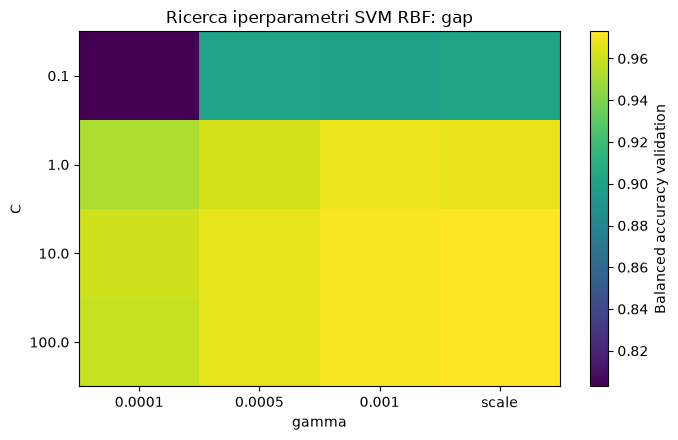

c:\Users\leona\venv_aml\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Users\leona\venv_aml\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Users\leona\venv_aml\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Users\leona\venv_aml\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed i

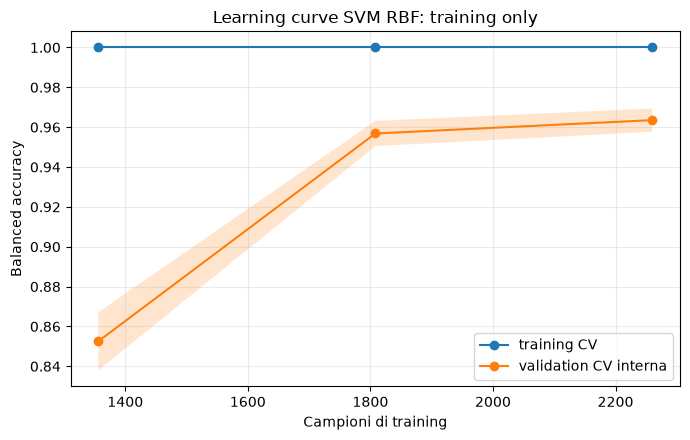

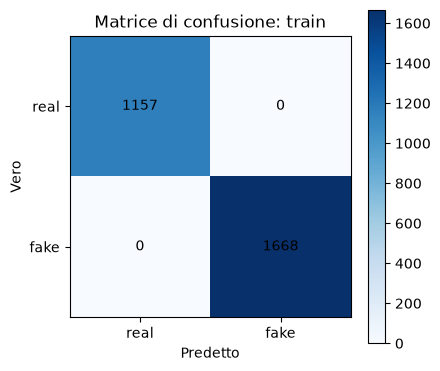

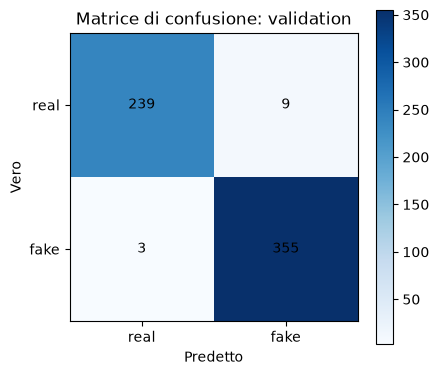

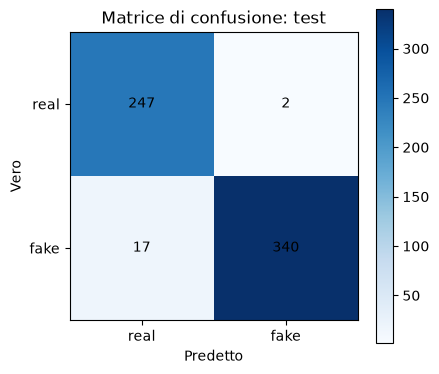

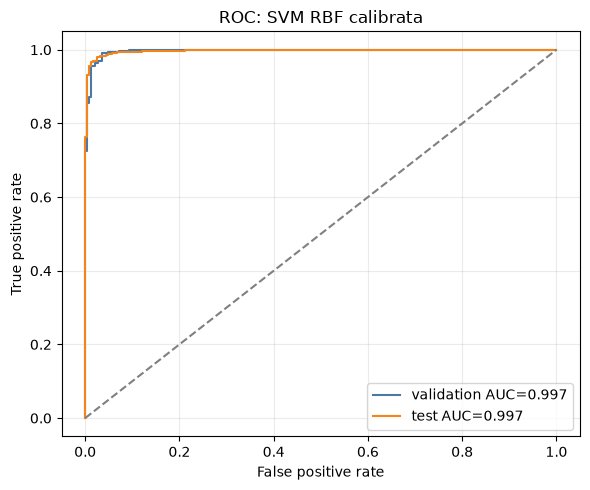

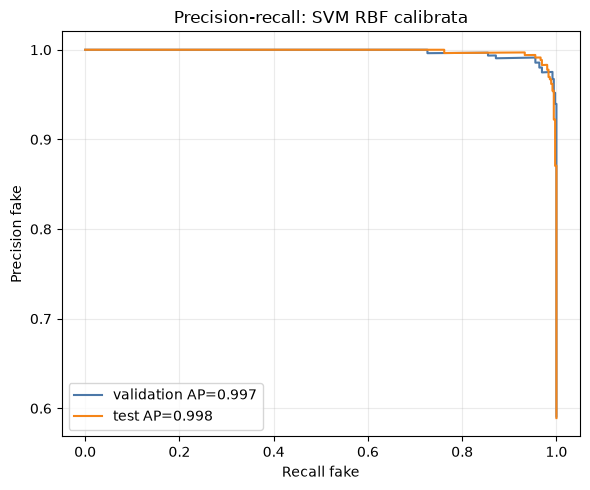

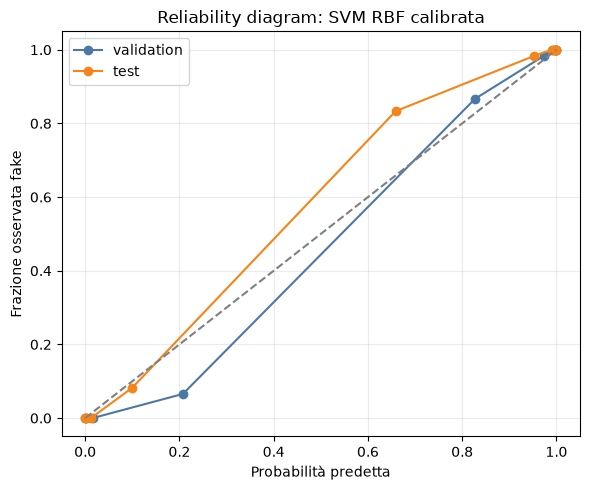

In [8]:
def save_figure(filename):
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / filename, dpi=200, bbox_inches='tight')
    plt.show()
    plt.close()

# La heatmap usa la configurazione di pooling e PCA selezionata, così mostra un confronto coerente di C e gamma.
heatmap_data = tuning_frame[(tuning_frame['pooling'] == selected_pooling) & (tuning_frame['class_weight'] == best_selection['class_weight']) & (tuning_frame['pca'] == best_selection['pca'])].copy()
heatmap_data['gamma_label'] = heatmap_data['gamma'].astype(str)
heatmap = heatmap_data.pivot(index='C', columns='gamma_label', values='validation_balanced_accuracy')
plt.figure(figsize=(7, 4.5))
image = plt.imshow(heatmap.to_numpy(), cmap='viridis', aspect='auto')
plt.colorbar(image, label='Balanced accuracy validation')
plt.xticks(range(len(heatmap.columns)), heatmap.columns)
plt.yticks(range(len(heatmap.index)), heatmap.index)
plt.xlabel('gamma')
plt.ylabel('C')
plt.title(f'Ricerca iperparametri SVM RBF: {selected_pooling}')
save_figure('hyperparameter_heatmap.png')

# Cross-validation interna al solo training: questa curva non guarda validation né test.
learning_estimator = make_svm_pipeline(best_selection['C'], best_selection['gamma'], best_selection['class_weight_value'], best_selection['pca_option'])
learning_cv = StratifiedKFold(n_splits=LEARNING_CURVE_FOLDS, shuffle=True, random_state=SEED)
sizes, train_scores, validation_scores = learning_curve(learning_estimator, X_train, y_train, train_sizes=LEARNING_CURVE_TRAIN_SIZES, cv=learning_cv, scoring='balanced_accuracy', n_jobs=1)
plt.figure(figsize=(7, 4.5))
plt.plot(sizes, train_scores.mean(axis=1), marker='o', label='training CV')
plt.fill_between(sizes, train_scores.mean(axis=1) - train_scores.std(axis=1), train_scores.mean(axis=1) + train_scores.std(axis=1), alpha=0.2)
plt.plot(sizes, validation_scores.mean(axis=1), marker='o', label='validation CV interna')
plt.fill_between(sizes, validation_scores.mean(axis=1) - validation_scores.std(axis=1), validation_scores.mean(axis=1) + validation_scores.std(axis=1), alpha=0.2)
plt.xlabel('Campioni di training')
plt.ylabel('Balanced accuracy')
plt.title('Learning curve SVM RBF: training only')
plt.legend()
plt.grid(alpha=0.25)
save_figure('learning_curve.png')

for split_name in ('train', 'validation', 'test'):
    matrix = evaluations[split_name][2]
    plt.figure(figsize=(4.5, 4))
    image = plt.imshow(matrix, cmap='Blues')
    plt.colorbar(image)
    plt.xticks([0, 1], ['real', 'fake'])
    plt.yticks([0, 1], ['real', 'fake'])
    plt.xlabel('Predetto')
    plt.ylabel('Vero')
    plt.title(f'Matrice di confusione: {split_name}')
    for row in range(2):
        for column in range(2):
            plt.text(column, row, str(matrix[row, column]), ha='center', va='center')
    save_figure(f'confusion_matrix_{split_name}.png')

plt.figure(figsize=(6, 5))
for split_name, color in (('validation', '#4c78a8'), ('test', '#f58518')):
    y_current = labels[validation_indices] if split_name == 'validation' else labels[test_indices]
    probabilities = evaluations[split_name][3]
    fpr, tpr, _ = roc_curve(y_current, probabilities, pos_label=POSITIVE_LABEL)
    plt.plot(fpr, tpr, color=color, label=f'{split_name} AUC={roc_auc_score(y_current, probabilities):.3f}')
plt.plot([0, 1], [0, 1], '--', color='grey')
plt.xlabel('False positive rate')
plt.ylabel('True positive rate')
plt.title('ROC: SVM RBF calibrata')
plt.legend(loc='lower right')
plt.grid(alpha=0.25)
save_figure('roc_curve.png')

plt.figure(figsize=(6, 5))
for split_name, color in (('validation', '#4c78a8'), ('test', '#f58518')):
    y_current = labels[validation_indices] if split_name == 'validation' else labels[test_indices]
    precision, recall, _ = precision_recall_curve(y_current, evaluations[split_name][3], pos_label=POSITIVE_LABEL)
    plt.plot(recall, precision, color=color, label=f'{split_name} AP={average_precision_score(y_current, evaluations[split_name][3]):.3f}')
plt.xlabel('Recall fake')
plt.ylabel('Precision fake')
plt.title('Precision-recall: SVM RBF calibrata')
plt.legend()
plt.grid(alpha=0.25)
save_figure('precision_recall_curve.png')

plt.figure(figsize=(6, 5))
for split_name, color in (('validation', '#4c78a8'), ('test', '#f58518')):
    y_current = labels[validation_indices] if split_name == 'validation' else labels[test_indices]
    observed, predicted = calibration_curve(y_current, evaluations[split_name][3], n_bins=10, strategy='quantile')
    plt.plot(predicted, observed, marker='o', color=color, label=split_name)
plt.plot([0, 1], [0, 1], '--', color='grey')
plt.xlabel('Probabilità predetta')
plt.ylabel('Frazione osservata fake')
plt.title('Reliability diagram: SVM RBF calibrata')
plt.legend()
plt.grid(alpha=0.25)
save_figure('calibration_curve.png')

## 8. Salvataggio, ricaricamento e riepilogo

Il bundle serializzato include pipeline, scaler, eventuale PCA, SVM calibrata, soglia, pooling e hash dello split. La verifica finale ricarica il bundle e controlla che le probabilità di validation coincidano entro tolleranza.

In [9]:
# Il bundle è autosufficiente per l'ensemble: tutti i trasformatori sono incapsulati nelle pipeline serializzate.
bundle = {'model_name': MODEL_NAME, 'run_id': RUN_ID, 'class_mapping': CLASS_MAPPING, 'positive_class': POSITIVE_CLASS, 'positive_label': POSITIVE_LABEL, 'pooling': selected_pooling, 'feature_dimension': int(X_train.shape[1]), 'selected_hyperparameters': {'C': best_selection['C'], 'gamma': best_selection['gamma'], 'class_weight': best_selection['class_weight'], 'pca': best_selection['pca']}, 'threshold': DECISION_THRESHOLD, 'threshold_selection_split': 'validation', 'calibration': {'method': 'sigmoid', 'cv_folds': CALIBRATION_FOLDS, 'fit_scope': 'training only'}, 'split_hash': SPLIT_HASH, 'selection_model': selection_model, 'calibrated_model': calibrated_model, 'versions': versions}
MODEL_PATH = RUN_DIR / 'best_model.joblib'
joblib.dump(bundle, MODEL_PATH)
reloaded_bundle = joblib.load(MODEL_PATH)
reloaded_probability = reloaded_bundle['calibrated_model'].predict_proba(X_validation)[:, POSITIVE_LABEL]
if not np.allclose(reloaded_probability, validation_probability, rtol=1e-6, atol=1e-7):
    raise RuntimeError('Le probabilità del modello ricaricato non coincidono con quelle originali')

summary = {'run_id': RUN_ID, 'model': MODEL_NAME, 'pooling': selected_pooling, 'selected_hyperparameters': bundle['selected_hyperparameters'], 'threshold': DECISION_THRESHOLD, 'split_hash': SPLIT_HASH, 'split_summary': SPLIT_SUMMARY, 'tuning_seconds': tuning_seconds, 'calibration_seconds': calibration_seconds, 'model_size_bytes': MODEL_PATH.stat().st_size, 'metrics': metrics_frame.to_dict(orient='records'), 'artifacts': {'model': str(MODEL_PATH), 'metrics': str(RUN_DIR / 'metrics.csv'), 'predictions': str(RUN_DIR / 'predictions.csv'), 'tuning': str(RUN_DIR / 'tuning_results.csv'), 'figures': str(FIGURES_DIR)}}
atomic_json(summary, RUN_DIR / 'summary.json')
print('Bundle ricaricato e probabilità validation verificate.')
print('Artefatti:')
for name, path in summary['artifacts'].items():
    print(f'- {name}: {path}')
display(metrics_frame[['split', 'balanced_accuracy', 'roc_auc', 'pr_auc', 'f1', 'threshold']])

Bundle ricaricato e probabilità validation verificate.
Artefatti:
- model: c:\Users\leona\venv_aml\results\svm_rbf\seed42_20260916T133639Z\best_model.joblib
- metrics: c:\Users\leona\venv_aml\results\svm_rbf\seed42_20260916T133639Z\metrics.csv
- predictions: c:\Users\leona\venv_aml\results\svm_rbf\seed42_20260916T133639Z\predictions.csv
- tuning: c:\Users\leona\venv_aml\results\svm_rbf\seed42_20260916T133639Z\tuning_results.csv
- figures: c:\Users\leona\venv_aml\results\svm_rbf\seed42_20260916T133639Z\figures


,split,balanced_accuracy,roc_auc,pr_auc,f1,threshold
0,train,1.000000,1.000000,1.000000,1.000000,0.57
1,validation,0.977665,0.996598,0.997496,0.983380,0.57
2,test,0.972174,0.997053,0.997932,0.972818,0.57
